In [2]:
# 检查kernel 位置
import sys
print(sys.executable)

d:\ProgramData\Anaconda3\python.exe


In [4]:
%matplotlib notebook

In [5]:
import warnings
warnings.filterwarnings('ignore')

<IPython.core.display.Javascript object>


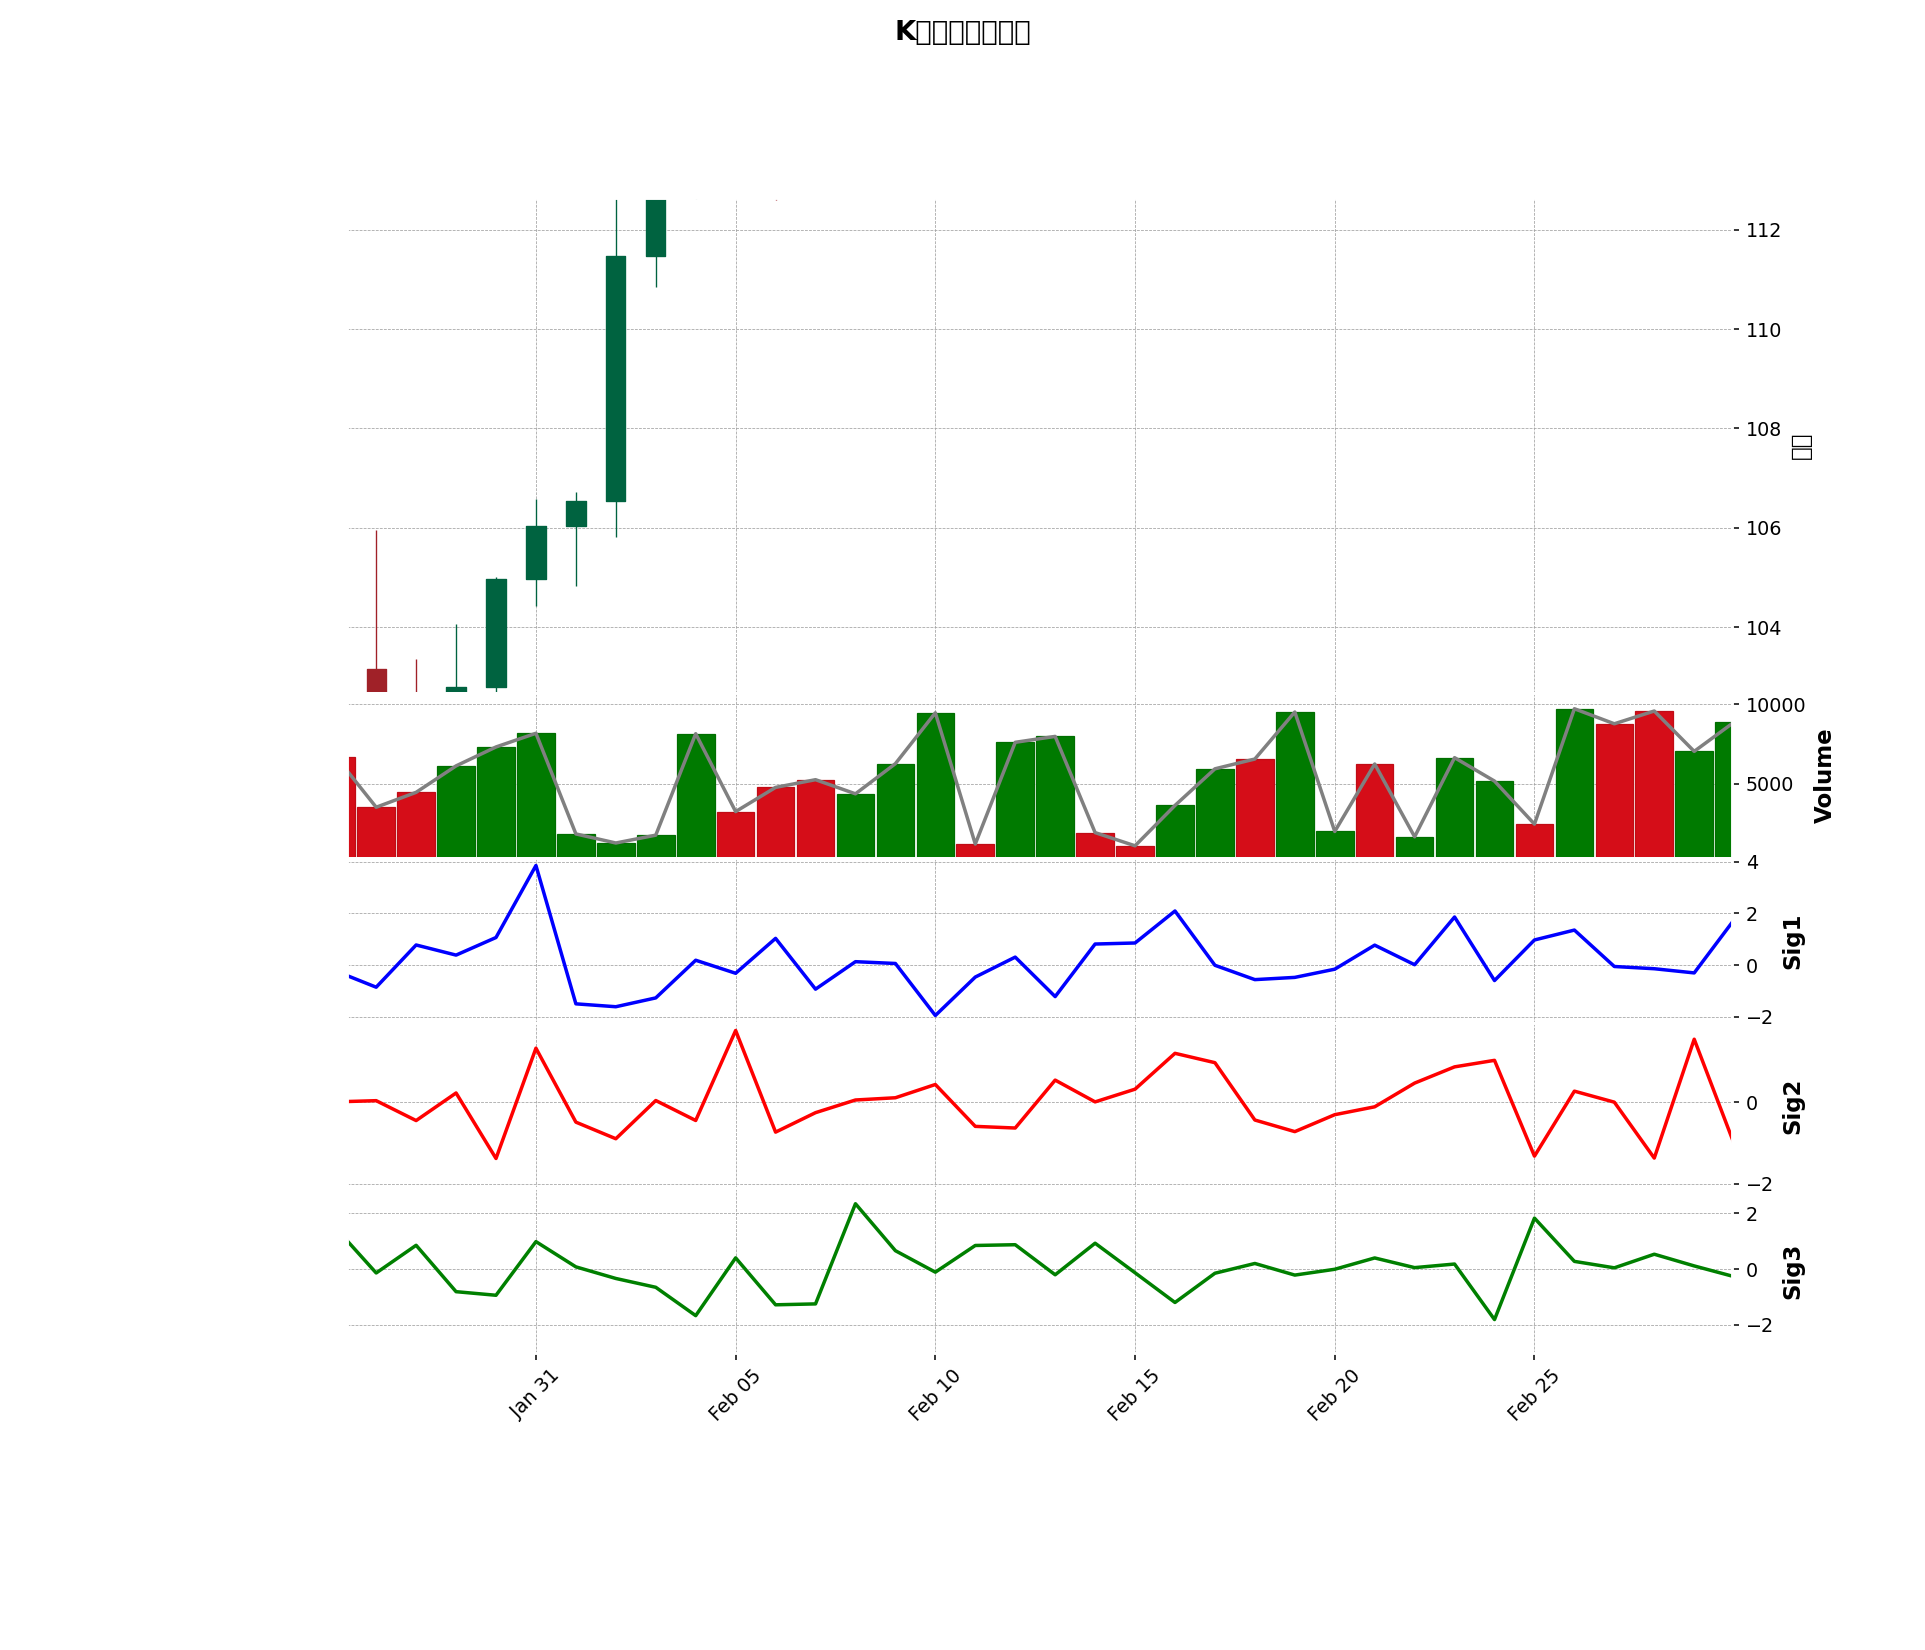

<IPython.core.display.Javascript object>


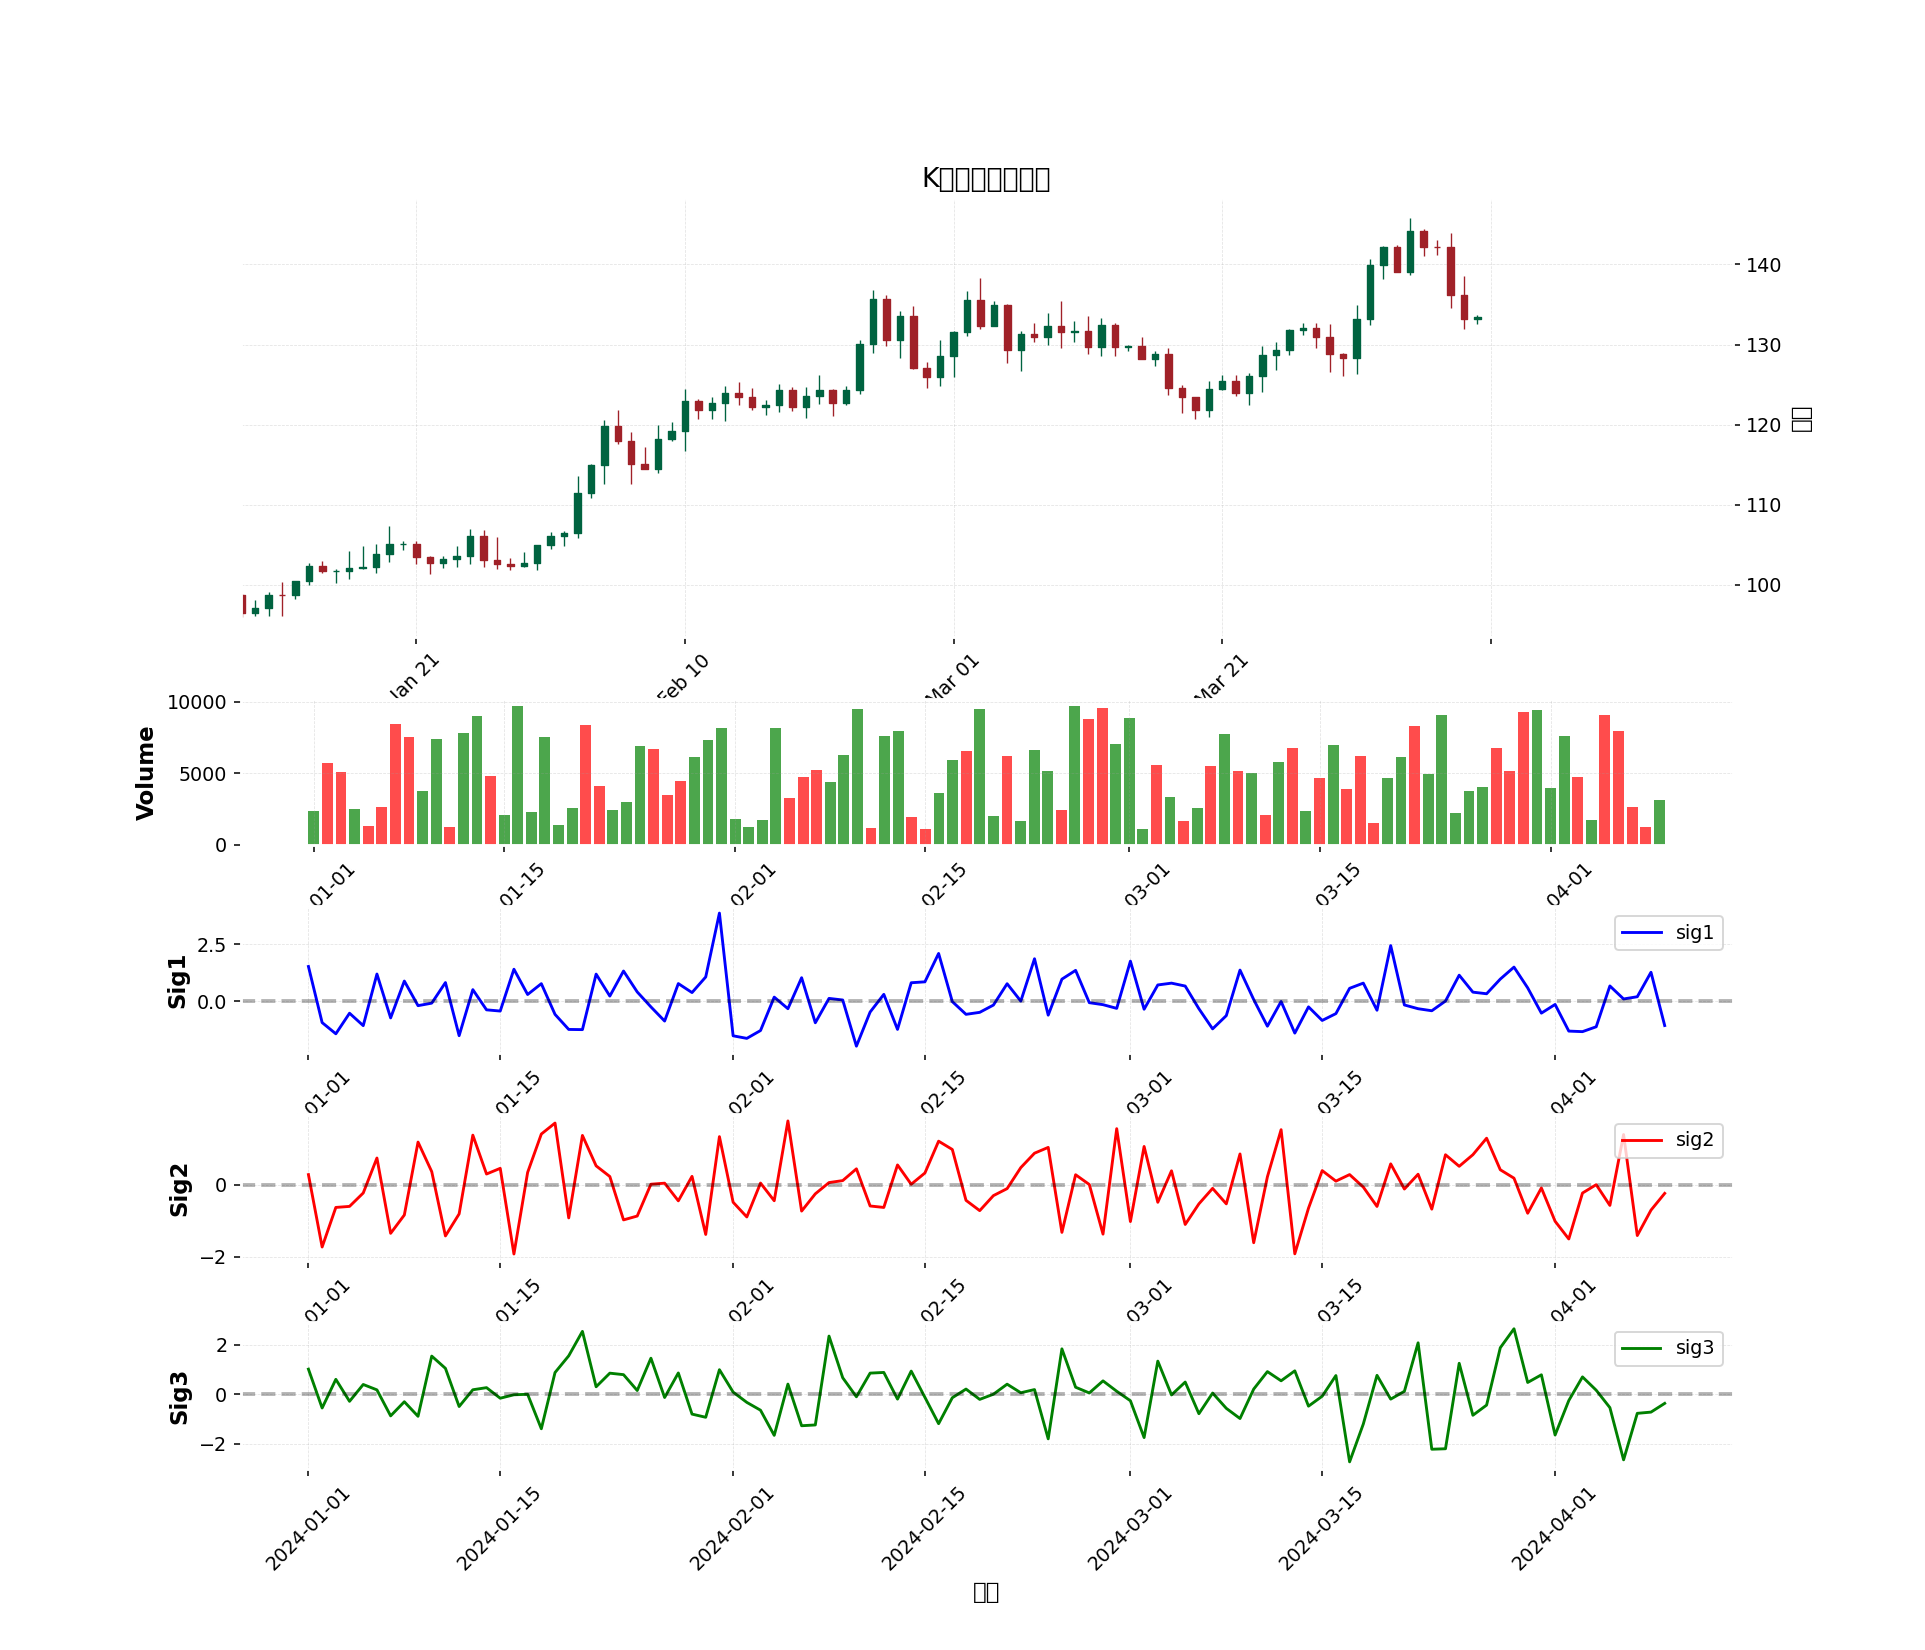

In [7]:
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt
import numpy as np

# 假设你的数据框已经存在
# base = pd.DataFrame(...)  # 你的数据框

# 示例数据生成（如果你没有实际数据，可以用这个测试）
def generate_sample_data(n=100):
    np.random.seed(42)
    dates = pd.date_range('2024-01-01', periods=n, freq='D')
    price = 100
    data = []
    for i in range(n):
        change = np.random.normal(0, 1)
        open_price = price
        close_price = price * (1 + change * 0.02)
        high_price = max(open_price, close_price) * (1 + abs(np.random.normal(0, 0.01)))
        low_price = min(open_price, close_price) * (1 - abs(np.random.normal(0, 0.01)))
        volume = int(np.random.uniform(1000, 10000))
        sig1 = np.random.randn()
        sig2 = np.random.randn()
        sig3 = np.random.randn()
        data.append([dates[i], open_price, high_price, low_price, close_price, volume, sig1, sig2, sig3])
        price = close_price
    return pd.DataFrame(data, columns=['time', 'open', 'high', 'low', 'close', 'volume', 'sig1', 'sig2', 'sig3'])

# 如果已有数据，注释掉上面这行，使用你的base数据框
base = generate_sample_data()

# 确保time列是datetime类型
base['time'] = pd.to_datetime(base['time'])
base.set_index('time', inplace=True)

# 方法1: 使用make_addplot添加副图
# 创建副图列表
apds = []

# 添加volume副图
apds.append(mpf.make_addplot(base['volume'], panel=1, color='gray', ylabel='Volume'))

# 添加sig1副图
apds.append(mpf.make_addplot(base['sig1'], panel=2, color='blue', ylabel='Sig1', 
                             secondary_y=False))

# 添加sig2副图
apds.append(mpf.make_addplot(base['sig2'], panel=3, color='red', ylabel='Sig2',
                             secondary_y=False))

# 添加sig3副图
apds.append(mpf.make_addplot(base['sig3'], panel=4, color='green', ylabel='Sig3',
                             secondary_y=False))

# 绘制K线图
fig, axes = mpf.plot(base, 
                      type='candle',  # K线图类型
                      style='charles',  # 样式：charles, yahoo, binance等
                      volume=True,  # 不显示默认的volume，因为我们在副图中显示
                      addplot=apds,
                      panel_ratios=(3, 1, 1, 1, 1),  # 主图和副图的高度比例
                      figsize=(14, 12),
                      title='K线图与信号指标',
                      ylabel='价格',
                      returnfig=True)

# 调整子图间距
plt.tight_layout()
plt.show()

# ============ 方法2: 更精细的控制 ============
def plot_custom_kline_with_indicators(df):
    """
    自定义绘制K线图和副图指标
    """
    # 创建figure和子图
    fig = plt.figure(figsize=(14, 12))
    
    # 创建网格布局：主图占3份，每个副图占1份
    gs = fig.add_gridspec(5, 1, height_ratios=[3, 1, 1, 1, 1], hspace=0.3)
    
    # 主图 - K线
    ax1 = fig.add_subplot(gs[0])
    
    # 绘制K线
    mpf.plot(df, 
             type='candle',
             style='charles',
             ax=ax1,
             volume=True,
             xrotation=45,
             ylabel='价格')
    
    ax1.set_title('K线图与信号指标', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # 副图1 - Volume
    ax2 = fig.add_subplot(gs[1])
    colors = ['green' if df['close'].iloc[i] >= df['open'].iloc[i] else 'red' 
              for i in range(len(df))]
    ax2.bar(df.index, df['volume'], color=colors, alpha=0.7)
    ax2.set_ylabel('Volume')
    ax2.grid(True, alpha=0.3)
    
    # 副图2 - sig1
    ax3 = fig.add_subplot(gs[2])
    ax3.plot(df.index, df['sig1'], color='blue', linewidth=1.5, label='sig1')
    ax3.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax3.set_ylabel('Sig1')
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='upper right')
    
    # 副图3 - sig2
    ax4 = fig.add_subplot(gs[3])
    ax4.plot(df.index, df['sig2'], color='red', linewidth=1.5, label='sig2')
    ax4.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax4.set_ylabel('Sig2')
    ax4.grid(True, alpha=0.3)
    ax4.legend(loc='upper right')
    
    # 副图4 - sig3
    ax5 = fig.add_subplot(gs[4])
    ax5.plot(df.index, df['sig3'], color='green', linewidth=1.5, label='sig3')
    ax5.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax5.set_ylabel('Sig3')
    ax5.grid(True, alpha=0.3)
    ax5.legend(loc='upper right')
    ax5.set_xlabel('时间')
    
    # 自动调整日期显示
    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# 调用自定义绘图函数
plot_custom_kline_with_indicators(base)

# ============ 方法3: 使用subplots简化版 ============
def plot_simple_kline(df):
    """
    简化版：使用make_addplot一次性完成
    """
    # 准备所有副图
    add_plots = [
        mpf.make_addplot(df['volume'], panel=1, type='bar', color='gray', ylabel='Volume'),
        mpf.make_addplot(df['sig1'], panel=2, color='blue', ylabel='Sig1'),
        mpf.make_addplot(df['sig2'], panel=3, color='red', ylabel='Sig2'),
        mpf.make_addplot(df['sig3'], panel=4, color='green', ylabel='Sig3')
    ]
    
    # 绘制
    mpf.plot(df,
             type='candle',
             style='yahoo',
             addplot=add_plots,
             panel_ratios=(4, 1, 1, 1, 1),
             figsize=(14, 12),
             title='K线图与多指标副图',
             ylabel='价格',
             xrotation=45)
    
    plt.show()

# 调用简化版
# plot_simple_kline(base)